In [1]:
!pip install pymongo pandas numpy scikit-learn joblib matplotlib


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install pymongo pandas numpy scikit-learn joblib matplotlib python-dotenv


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
from pymongo import MongoClient
from dotenv import load_dotenv
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [48]:
env_path = Path("../../backend/.env")
load_dotenv(dotenv_path=env_path)

MONGO_URI = os.getenv("MONGO_URI")

print("Mongo URI loaded:", MONGO_URI is not None)

client = MongoClient(MONGO_URI)
db = client["asthmaDB"]
collection = db["sensordatas"]

data = list(collection.find())
print("Total documents fetched:", len(data))

Mongo URI loaded: True
Total documents fetched: 846


In [49]:
df = pd.DataFrame(data)
df.head()

,_id,co_ppm,o3_ppb,no2_ppb,temperature,humidity,pm1,pm25,pm10,timestamp,__v,location
0,69cd4113a4a4330da357a57c,3.705689,10.0,8.413441,31.7,50,20,29,29,2026-04-01 16:00:19.095,0,"{'latitude': 26.1243, 'longitude': 91.76}"
1,69cd411fa4a4330da357a584,3.743311,10.0,8.080150,31.9,50,20,29,29,2026-04-01 16:00:31.052,0,"{'latitude': 24.84314758813627, 'longitude': 9..."
2,69cd412da4a4330da357a588,3.689696,10.0,8.443026,31.9,49,20,29,29,2026-04-01 16:00:45.495,0,NaN
3,69cd4139a4a4330da357a58a,3.652678,10.0,8.592427,31.9,49,19,28,28,2026-04-01 16:00:57.984,0,NaN
4,69cd4146a4a4330da357a58c,3.595344,10.0,8.867670,31.8,49,19,28,28,2026-04-01 16:01:10.134,0,NaN


In [50]:
required_cols = [
    "co_ppm",
    "o3_ppb",
    "no2_ppb",
    "temperature",
    "humidity",
    "pm1",
    "pm25",
    "pm10"
]

df = df[required_cols].copy()
df.head()

,co_ppm,o3_ppb,no2_ppb,temperature,humidity,pm1,pm25,pm10
0,3.705689,10.0,8.413441,31.7,50,20,29,29
1,3.743311,10.0,8.080150,31.9,50,20,29,29
2,3.689696,10.0,8.443026,31.9,49,20,29,29
3,3.652678,10.0,8.592427,31.9,49,19,28,28
4,3.595344,10.0,8.867670,31.8,49,19,28,28


In [51]:
print(df.isnull().sum())

co_ppm         0
o3_ppb         0
no2_ppb        0
temperature    0
humidity       0
pm1            0
pm25           0
pm10           0
dtype: int64


In [52]:
for col in required_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dropna(inplace=True)

print("Rows after cleaning:", len(df))
df.head()

Rows after cleaning: 846


,co_ppm,o3_ppb,no2_ppb,temperature,humidity,pm1,pm25,pm10
0,3.705689,10.0,8.413441,31.7,50,20,29,29
1,3.743311,10.0,8.080150,31.9,50,20,29,29
2,3.689696,10.0,8.443026,31.9,49,20,29,29
3,3.652678,10.0,8.592427,31.9,49,19,28,28
4,3.595344,10.0,8.867670,31.8,49,19,28,28


In [53]:
df.describe()

,co_ppm,o3_ppb,no2_ppb,temperature,humidity,pm1,pm25,pm10
count,846.000000,846.000000,8.460000e+02,846.000000,846.000000,846.000000,846.000000,846.00000
mean,62.580599,10.003992,6.749356e+00,30.904610,52.527187,56.908983,161.979905,191.91844
std,766.738896,0.116113,2.083332e+00,1.022951,2.374638,70.653702,294.247762,378.06706
min,1.553421,10.000000,1.402872e-13,27.500000,42.000000,0.000000,0.000000,0.00000
25%,1.905653,10.000000,6.155241e+00,30.200000,51.000000,22.000000,31.000000,34.00000
50%,2.264972,10.000000,7.152575e+00,31.250000,52.000000,23.000000,33.000000,38.00000
75%,3.492403,10.000000,8.005830e+00,31.500000,54.000000,32.750000,49.000000,59.00000
max,10000.000000,13.377280,1.087405e+01,35.200000,62.000000,256.000000,1493.000000,2173.00000


In [82]:
def label_pm1(x):
    if x > 35:
        return 2
    elif x >= 10:
        return 1
    else:
        return 0

def label_pm25(x):
    if x > 35:
        return 2
    elif x >= 16:
        return 1
    else:
        return 0

def label_pm10(x):
    if x > 100:
        return 2
    elif x >= 46:
        return 1
    else:
        return 0

def label_no2(x):
    if x > 51:
        return 2
    elif x >= 21:
        return 1
    else:
        return 0

def label_o3(x):
    if x > 61:
        return 2
    elif x >= 36:
        return 1
    else:
        return 0

def label_co(x):
    if x > 6:
        return 2
    elif x >= 2.1:
        return 1
    else:
        return 0

def label_temperature(x):
    if x <= 15 or x >= 35:
        return 2
    elif (15 < x < 20) or (30 < x < 35):
        return 1
    else:
        return 0


def label_humidity(x):
    if x > 60:
        return 2
    elif x < 30 or (50 < x <= 60):
        return 1
    else:
        return 0

def assign_environment_label(row):
    labels = [
        label_pm1(row["pm1"]),
        label_pm25(row["pm25"]),
        label_pm10(row["pm10"]),
        label_no2(row["no2_ppb"]),
        label_o3(row["o3_ppb"]),
        label_co(row["co_ppm"]),
        label_temperature(row["temperature"]),
        label_humidity(row["humidity"])
    ]
    
    return (labels)

In [83]:
df["pm1_label"] = df["pm1"].apply(label_pm1)
df["pm25_label"] = df["pm25"].apply(label_pm25)
df["pm10_label"] = df["pm10"].apply(label_pm10)
df["no2_label"] = df["no2_ppb"].apply(label_no2)
df["o3_label"] = df["o3_ppb"].apply(label_o3)
df["co_label"] = df["co_ppm"].apply(label_co)
df["temperature_label"] = df["temperature"].apply(label_temperature)
df["humidity_label"] = df["humidity"].apply(label_humidity)

df["label_sum"] = df[
    [
        "pm1_label",
        "pm25_label",
        "pm10_label",
        "no2_label",
        "o3_label",
        "co_label",
        "temperature_label",
        "humidity_label"
    ]
].sum(axis=1)

def final_risk_from_sum(total):
    if total >= 7:
        return 2
    elif total >= 3:
        return 1
    else:
        return 0

df["risk_label"] = df["label_sum"].apply(final_risk_from_sum)

df[[
    "pm1", "pm25", "pm10", "co_ppm", "temperature", "humidity",
    "pm1_label", "pm25_label", "pm10_label", "co_label",
    "temperature_label", "humidity_label", "label_sum", "risk_label"
]].head()

,pm1,pm25,pm10,co_ppm,temperature,humidity,pm1_label,pm25_label,pm10_label,co_label,temperature_label,humidity_label,label_sum,risk_label
0,20,29,29,3.705689,31.7,50,1,1,0,1,1,0,4,1
1,20,29,29,3.743311,31.9,50,1,1,0,1,1,0,4,1
2,20,29,29,3.689696,31.9,49,1,1,0,1,1,0,4,1
3,19,28,28,3.652678,31.9,49,1,1,0,1,1,0,4,1
4,19,28,28,3.595344,31.8,49,1,1,0,1,1,0,4,1


In [84]:
print(df["risk_label"].value_counts())
print()
print(df["risk_label"].value_counts(normalize=True) * 100)

risk_label
1    627
2    219
Name: count, dtype: int64

risk_label
1    74.113475
2    25.886525
Name: proportion, dtype: float64


In [75]:
X = df[required_cols]
y = df["risk_label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (846, 8)
y shape: (846,)


In [76]:
df["co_ppm"] = df["co_ppm"].clip(upper=50)

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 676
Testing samples: 170


In [85]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [86]:
y_pred = rf_model.predict(X_test)

y_pred[:10]

array([2, 1, 1, 2, 1, 1, 2, 2, 1, 1])

In [87]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print()

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9823529411764705

Classification Report:
              precision    recall  f1-score   support

           1       0.98      1.00      0.99       126
           2       1.00      0.93      0.96        44

    accuracy                           0.98       170
   macro avg       0.99      0.97      0.98       170
weighted avg       0.98      0.98      0.98       170

Confusion Matrix:
[[126   0]
 [  3  41]]


In [64]:
feature_importance = pd.DataFrame({
    "feature": required_cols,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
7,pm10,0.284287
5,pm1,0.258178
6,pm25,0.203981
2,no2_ppb,0.144641
0,co_ppm,0.052485
4,humidity,0.030491
3,temperature,0.025937
1,o3_ppb,0.000000


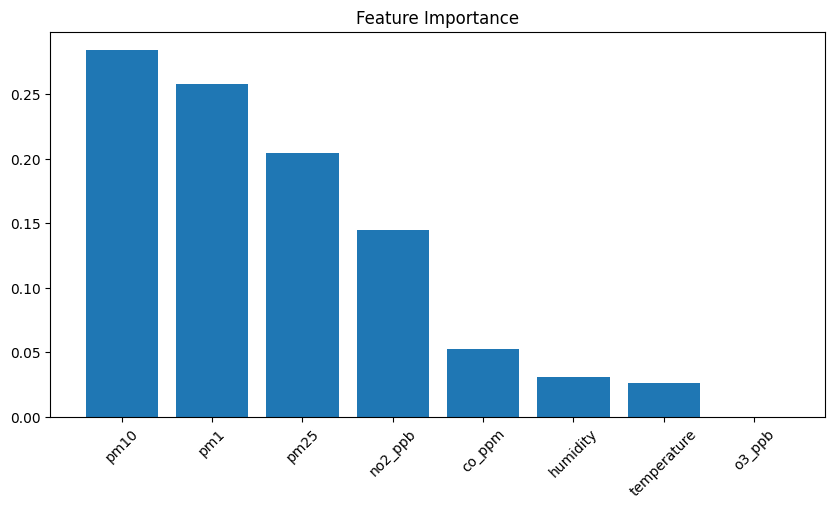

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(feature_importance["feature"], feature_importance["importance"])

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()

In [66]:
def probability_to_risk_score(model, sample_df):
    probs = model.predict_proba(sample_df)[0]
    classes = model.classes_

    prob_map = {int(cls): float(prob) for cls, prob in zip(classes, probs)}

    p_safe = prob_map.get(0, 0.0)
    p_moderate = prob_map.get(1, 0.0)
    p_high = prob_map.get(2, 0.0)

    risk_score = (0.0 * p_safe) + (0.5 * p_moderate) + (1.0 * p_high)

    return float(risk_score), prob_map

In [67]:
sample = X_test.iloc[[0]]

predicted_label = rf_model.predict(sample)[0]
risk_score, probs = probability_to_risk_score(rf_model, sample)

print("Predicted label:", predicted_label)
print("Probabilities:", probs)
print("Environmental risk score:", float(risk_score))

Predicted label: 2
Probabilities: {1: 0.0, 2: 1.0}
Environmental risk score: 1.0


In [68]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

bundle = {
    "model": rf_model,
    "features": required_cols
}

joblib.dump(bundle, "../models/environment_rf_bundle.pkl")
print("Model saved to ../models/environment_rf_bundle.pkl")

Model saved to ../models/environment_rf_bundle.pkl


In [69]:
#read the file
import joblib

bundle = joblib.load("../models/environment_rf_bundle.pkl")

print(bundle.keys())

dict_keys(['model', 'features'])


In [70]:
#Inspect the contents
model = bundle["model"]
features = bundle["features"]

print("Features:", features)
print("Model:", model)

Features: ['co_ppm', 'o3_ppb', 'no2_ppb', 'temperature', 'humidity', 'pm1', 'pm25', 'pm10']
Model: RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)


In [71]:
#Test prediction using the saved model
import pandas as pd

sample = pd.DataFrame([{
    "co_ppm": 3.7,
    "o3_ppb": 10,
    "no2_ppb": 8.4,
    "temperature": 31.7,
    "humidity": 50,
    "pm1": 20,
    "pm25": 29,
    "pm10": 29
}])[features]

prediction = model.predict(sample)

print(prediction)

[1]


Mongo URI loaded: True
Total documents fetched: 1917
No recordedAt column found — temporal features skipped

Null counts before cleaning:
co_ppm         0
o3_ppb         0
no2_ppb        0
temperature    0
humidity       0
pm1            0
pm25           0
pm10           0
dtype: int64
Rows dropped due to bad NO2 readings: 5
Rows after cleaning: 1912
            co_ppm  o3_ppb      no2_ppb  temperature     humidity  \
count  1912.000000  1912.0  1912.000000  1912.000000  1912.000000   
mean      2.748768    10.0     9.894682    29.554969    51.694038   
std       4.904641     0.0     4.459545     2.807508     6.210591   
min       0.645813    10.0     0.039561    19.600000    31.000000   
25%       1.259289    10.0     7.045378    28.600000    50.000000   
50%       1.880443    10.0     9.103414    30.200000    52.000000   
75%       2.627079    10.0    11.535790    31.400000    55.000000   
max      50.000000    10.0    23.438030    35.200000    66.000000   

               pm1       

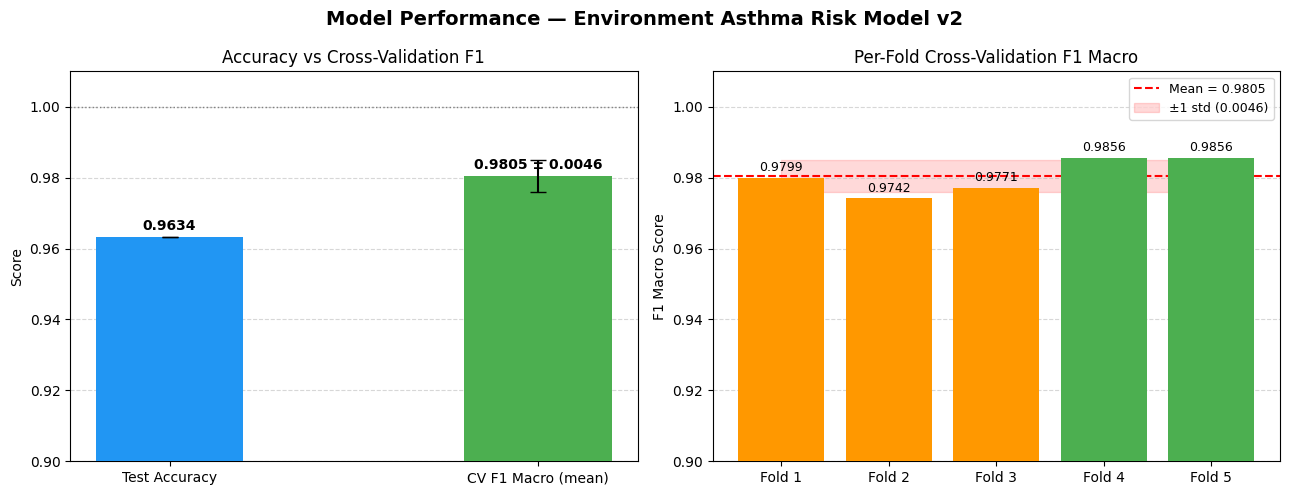


PERFORMANCE SUMMARY
  Test Accuracy        : 0.9634 (96.34%)
  CV F1 Macro (mean)   : 0.9805
  CV F1 Macro (std)    : ±0.0046
  CV F1 Macro (range)  : 0.9742 – 0.9856

Feature Importance:
    feature  importance
       pm10    0.216051
       pm25    0.196499
        pm1    0.159526
     co_ppm    0.136839
    no2_ppb    0.106421
   humidity    0.095102
temperature    0.089561
     o3_ppb    0.000000


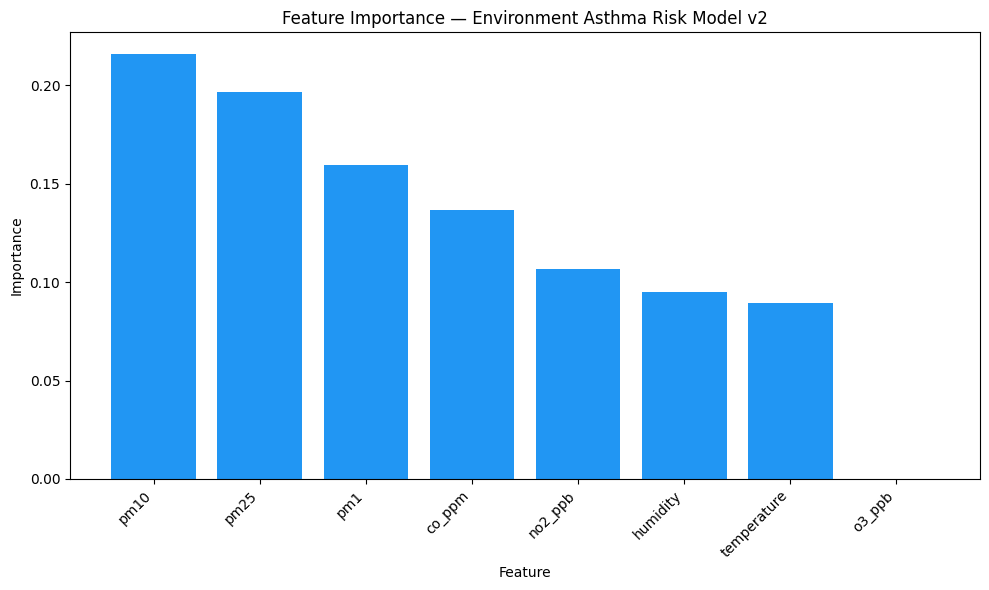

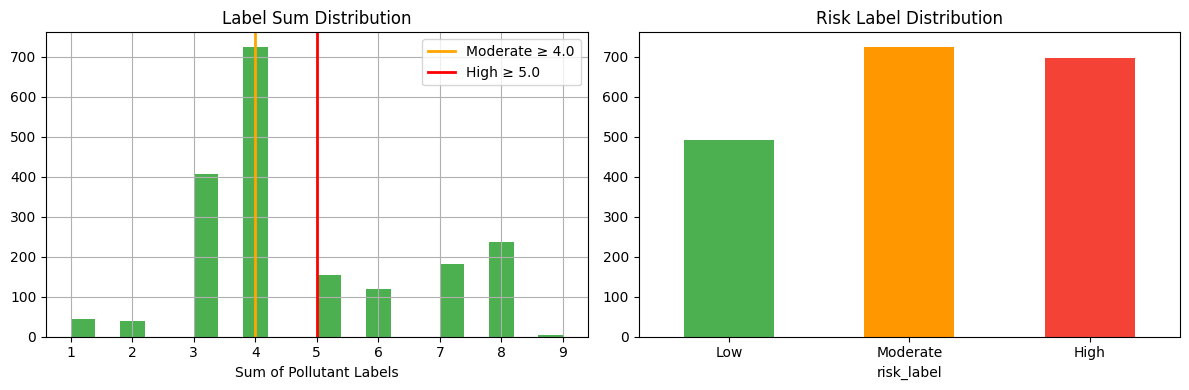


--- Sample Prediction (from test set) ---
Predicted label:         High
Probabilities:           {0: 0.0, 1: 0.0, 2: 1.0}
Environmental risk score: 1.0

Model saved to ../models/environment_rf_bundle_v2.pkl
Labeled dataset saved to ../data_exports/environment_risk_training_data_labeled_v2.csv

Loaded bundle keys: ['model', 'features', 'label_map', 'thresholds', 'notes']
Features: ['co_ppm', 'o3_ppb', 'no2_ppb', 'temperature', 'humidity', 'pm1', 'pm25', 'pm10']
Thresholds: {'moderate_threshold': 4.0, 'high_threshold': 5.0}

--- Manual Sample Prediction ---
Predicted label:          Low
Probabilities:            {0: 0.9975, 1: 0.0, 2: 0.0025}
Environmental risk score: 0.0025


In [5]:
# ============================================================
# train_environment_model_v2.py
# Environment-Only Asthma Risk Model — Corrected & Improved
# Fixes: CPCB asthma-adjusted thresholds (all 8 pollutants
#        including PM1), SMOTE, percentile-based labels,
#        temporal features, cross-validation, no leakage
#        (no cross join here so leakage fix is N/A)
# ============================================================

import os
from pathlib import Path

import pandas as pd
import numpy as np
from pymongo import MongoClient
from dotenv import load_dotenv
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
env_path = Path("../../backend/.env")
load_dotenv(dotenv_path=env_path)

MONGO_URI = os.getenv("MONGO_URI")
print("Mongo URI loaded:", MONGO_URI is not None)

client = MongoClient(MONGO_URI)
db = client["asthmaDB"]
collection = db["sensordatas"]

data = list(collection.find())
print("Total documents fetched:", len(data))

df = pd.DataFrame(data)

# ─────────────────────────────────────────────
# 2. SELECT REQUIRED COLUMNS
# ─────────────────────────────────────────────
sensor_cols = [
    "co_ppm", "o3_ppb", "no2_ppb",
    "temperature", "humidity",
    "pm1", "pm25", "pm10"
]

# Keep recordedAt for temporal features
cols_to_load = sensor_cols + (["recordedAt"] if "recordedAt" in df.columns else [])
df = df[[c for c in cols_to_load if c in df.columns]].copy()

# ─────────────────────────────────────────────
# 3. PARSE TIMESTAMPS & EXTRACT TEMPORAL FEATURES
# ─────────────────────────────────────────────
if "recordedAt" in df.columns:
    df["recordedAt"] = pd.to_datetime(df["recordedAt"], errors="coerce")

    df["hour"]        = df["recordedAt"].dt.hour.fillna(0).astype(int)
    df["month"]       = df["recordedAt"].dt.month.fillna(1).astype(int)
    df["day_of_week"] = df["recordedAt"].dt.dayofweek.fillna(0).astype(int)

    # Cyclical encoding — hour 23 and hour 0 are neighbours
    df["hour_sin"]  = np.sin(2 * np.pi * df["hour"]  / 24)
    df["hour_cos"]  = np.cos(2 * np.pi * df["hour"]  / 24)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df.drop(columns=["recordedAt", "hour", "month"], inplace=True)
    temporal_cols = ["hour_sin", "hour_cos", "month_sin", "month_cos", "day_of_week"]
    print("Temporal features added:", temporal_cols)
else:
    temporal_cols = []
    print("No recordedAt column found — temporal features skipped")

# ─────────────────────────────────────────────
# 4. CLEAN NUMERICS
# ─────────────────────────────────────────────
print("\nNull counts before cleaning:")
print(df[sensor_cols].isnull().sum())

for col in sensor_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dropna(subset=sensor_cols, inplace=True)

# ── Clip sensor outliers ──────────────────────
# CO: physical max in real environments ~50 ppm
df["co_ppm"] = df["co_ppm"].clip(upper=50)

# PM caps — CPCB Severe+ ceiling; values above these
# are almost certainly sensor spikes, not real readings
df["pm1"]  = df["pm1"].clip(upper=200)
df["pm25"] = df["pm25"].clip(upper=500)
df["pm10"] = df["pm10"].clip(upper=600)

# ── Clean NO2 ─────────────────────────────────
# Values at or below 0 (e.g. 1.4e-13) are bad sensor
# readings — replace with NaN and drop those rows
df["no2_ppb"] = df["no2_ppb"].where(df["no2_ppb"] > 0.01, other=np.nan)
rows_before = len(df)
df.dropna(subset=["no2_ppb"], inplace=True)
print(f"Rows dropped due to bad NO2 readings: {rows_before - len(df)}")

print("Rows after cleaning:", len(df))
print(df[sensor_cols].describe())

# ─────────────────────────────────────────────
# 5. ASTHMA-ADJUSTED CPCB/NAQI THRESHOLDS
# Asthma airways are 2-3x more sensitive than
# general public. All thresholds tightened accordingly.
# Sources: CPCB NAQI 2014, GINA 2023, WHO AQG 2021
# ─────────────────────────────────────────────

# PM1 — no official CPCB standard; WHO ultrafine guidance
# Ultrafine particles penetrate deepest into asthmatic airways
def label_pm1_asthma(x):
    if x > 35:      # High — ultrafine overload
        return 2
    elif x >= 10:    # Moderate — noticeable irritation
        return 1
    else:
        return 0

# PM2.5 — CPCB 24hr: Good≤30, Satisfactory≤60, Moderate≤90
# Asthma trigger risk starts at 30 µg/m³ (vs 60 for general public)
def label_pm25_asthma(x):
    if x > 60:      # CPCB Moderate+ → High for asthma
        return 2
    elif x >= 30:   # CPCB Satisfactory → already risky for asthma
        return 1
    else:
        return 0

# PM10 — CPCB 24hr: Good≤50, Satisfactory≤100
# Asthma patients sensitive from 50 µg/m³
def label_pm10_asthma(x):
    if x > 100:     # CPCB Moderate → High for asthma
        return 2
    elif x >= 50:   # CPCB Satisfactory → Moderate for asthma
        return 1
    else:
        return 0

# NO2 — CPCB: Good≤40 µg/m³; convert ppb→µg/m³ (×1.88)
# Asthma: WHO recommends <25 µg/m³ annual; short spikes harmful
def label_no2_asthma(x_ppb):
    x = x_ppb * 1.88   # convert to µg/m³
    if x > 180:         # CPCB Poor → High
        return 2
    elif x >= 40:       # CPCB Good ceiling → Moderate for asthma
        return 1
    else:
        return 0

# O3 — CPCB: Good≤50 µg/m³; convert ppb→µg/m³ (×1.96)
# O3 is one of the strongest known asthma triggers
def label_o3_asthma(x_ppb):
    x = x_ppb * 1.96   # convert to µg/m³
    if x > 100:         # CPCB Moderate → High for asthma
        return 2
    elif x >= 50:       # CPCB Good ceiling → already problematic
        return 1
    else:
        return 0

# CO — CPCB: Good≤1 mg/m³; convert ppm→mg/m³ (×1.145)
def label_co_asthma(x_ppm):
    x = x_ppm * 1.145  # convert to mg/m³
    if x > 10:          # CPCB Poor
        return 2
    elif x >= 2.0:      # Moderate; asthma patients affected earlier
        return 1
    else:
        return 0

# Temperature — physiological, not CPCB
# Cold air (<10°C) triggers bronchospasm; heat (>32°C) worsens inflammation
def label_temperature_asthma(x):
    if x <= 10 or x >= 32:         # tighter than general (was 15/35)
        return 2
    elif (10 < x < 16) or (28 < x < 32):
        return 1
    else:
        return 0

# Humidity — high humidity promotes mold/dust mites (key asthma triggers)
# Low humidity dries and irritates airways
def label_humidity_asthma(x):
    if x > 65 or x < 25:           # tighter upper bound (was 60)
        return 2
    elif x > 55 or x < 35:
        return 1
    else:
        return 0

# Apply labels
df["pm1_label"]         = df["pm1"].apply(label_pm1_asthma)
df["pm25_label"]        = df["pm25"].apply(label_pm25_asthma)
df["pm10_label"]        = df["pm10"].apply(label_pm10_asthma)
df["no2_label"]         = df["no2_ppb"].apply(label_no2_asthma)
df["o3_label"]          = df["o3_ppb"].apply(label_o3_asthma)
df["co_label"]          = df["co_ppm"].apply(label_co_asthma)
df["temperature_label"] = df["temperature"].apply(label_temperature_asthma)
df["humidity_label"]    = df["humidity"].apply(label_humidity_asthma)

label_cols = [
    "pm1_label", "pm25_label", "pm10_label",
    "no2_label", "o3_label", "co_label",
    "temperature_label", "humidity_label"
]

df["label_sum"] = df[label_cols].sum(axis=1)

print("\nLabel sum distribution:")
print(df["label_sum"].describe())

# ─────────────────────────────────────────────
# 6. PERCENTILE-BASED RISK LABEL THRESHOLDS
# Uses 33rd/66th percentile for balanced classes
# instead of fixed cutoffs (was ≥7/≥3)
# ─────────────────────────────────────────────
p33 = df["label_sum"].quantile(0.33)
p66 = df["label_sum"].quantile(0.66)
print(f"\nPercentile thresholds → Moderate: ≥{p33:.2f}, High: ≥{p66:.2f}")

def final_risk_label(total, t_mod=p33, t_high=p66):
    if total >= t_high:   return 2  # High
    elif total >= t_mod:  return 1  # Moderate
    else:                 return 0  # Low

df["risk_label"] = df["label_sum"].apply(final_risk_label)

print("\nRisk label distribution:")
print(df["risk_label"].value_counts())
print()
print(df["risk_label"].value_counts(normalize=True).mul(100).round(1))

# Preview
print("\nSample rows:")
print(df[[
    "pm1", "pm25", "pm10", "co_ppm", "temperature", "humidity",
    "pm1_label", "pm25_label", "pm10_label", "co_label",
    "temperature_label", "humidity_label", "label_sum", "risk_label"
]].head())

# ─────────────────────────────────────────────
# 7. FEATURE COLUMNS
# ─────────────────────────────────────────────
feature_cols = sensor_cols + temporal_cols
# Only keep what actually exists in df
feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols].copy()
y = df["risk_label"].copy()

print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("Features:", feature_cols)

# ─────────────────────────────────────────────
# 8. TRAIN / TEST SPLIT
# No cross join in this model so standard split is fine
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples: ", len(X_test))

# ─────────────────────────────────────────────
# 9. SMOTE — HANDLE CLASS IMBALANCE
# Dynamically upsamples minority classes
# ─────────────────────────────────────────────
class_counts = y_train.value_counts()
print("\nBefore SMOTE:", class_counts.to_dict())

target_count = max(int(len(y_train) * 0.20), class_counts.max())

sampling_strategy = {
    cls: target_count
    for cls, cnt in class_counts.items()
    if cnt < target_count
}

if sampling_strategy:
    k_neighbors = min(5, min(class_counts.values) - 1)
    k_neighbors = max(1, k_neighbors)
    sm = SMOTE(
        sampling_strategy=sampling_strategy,
        random_state=42,
        k_neighbors=k_neighbors
    )
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
    print("After SMOTE: ", pd.Series(y_train_res).value_counts().to_dict())
else:
    X_train_res, y_train_res = X_train, y_train
    print("SMOTE not needed — classes already balanced")

# ─────────────────────────────────────────────
# 10. TRAIN MODEL
# ─────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train_res, y_train_res)
print("\nModel trained successfully")

# ─────────────────────────────────────────────
# 11. EVALUATE
# ─────────────────────────────────────────────
y_pred = rf_model.predict(X_test)

print("\n" + "="*50)
print("EVALUATION ON HELD-OUT TEST SET")
print("="*50)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Low", "Moderate", "High"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Cross-validation — honest generalization estimate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    RandomForestClassifier(
        n_estimators=200, random_state=42,
        class_weight="balanced", n_jobs=-1
    ),
    X_train_res, y_train_res,
    cv=cv, scoring="f1_macro"
)
print(f"\n5-Fold CV F1 Macro: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print("(More reliable than single-split accuracy)")

# ─────────────────────────────────────────────
# 12. ACCURACY & CV RESULTS VISUALIZATION
# ─────────────────────────────────────────────
test_accuracy = round(accuracy_score(y_test, y_pred), 4)
cv_mean       = round(cv_scores.mean(), 4)
cv_std        = round(cv_scores.std(), 4)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Model Performance — Environment Asthma Risk Model v2", fontsize=14, fontweight="bold")

# ── Left: Accuracy bar ──────────────────────
metrics      = ["Test Accuracy", "CV F1 Macro (mean)"]
values       = [test_accuracy, cv_mean]
error_values = [0, cv_std]
colors       = ["#2196F3", "#4CAF50"]

bars = axes[0].bar(metrics, values, color=colors, width=0.4, zorder=3)
axes[0].errorbar(
    metrics, values,
    yerr=error_values,
    fmt="none", color="black", capsize=6, linewidth=1.5, zorder=4
)
axes[0].set_ylim(0.90, 1.01)
axes[0].set_ylabel("Score")
axes[0].set_title("Accuracy vs Cross-Validation F1")
axes[0].grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
axes[0].axhline(1.0, color="gray", linestyle=":", linewidth=1)

# Annotate bars
for bar, val, err in zip(bars, values, error_values):
    label = f"{val:.4f}" if err == 0 else f"{val:.4f} ± {err:.4f}"
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        label, ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

# ── Right: Per-fold CV scores ────────────────
fold_labels = [f"Fold {i+1}" for i in range(len(cv_scores))]
fold_colors = ["#4CAF50" if s >= cv_mean else "#FF9800" for s in cv_scores]

axes[1].bar(fold_labels, cv_scores, color=fold_colors, zorder=3)
axes[1].axhline(cv_mean, color="red", linestyle="--", linewidth=1.5,
                label=f"Mean = {cv_mean:.4f}")
axes[1].fill_between(
    range(len(cv_scores)),
    cv_mean - cv_std, cv_mean + cv_std,
    alpha=0.15, color="red", label=f"±1 std ({cv_std:.4f})"
)
axes[1].set_ylim(0.90, 1.01)
axes[1].set_ylabel("F1 Macro Score")
axes[1].set_title("Per-Fold Cross-Validation F1 Macro")
axes[1].legend(fontsize=9)
axes[1].grid(axis="y", linestyle="--", alpha=0.5, zorder=0)

for i, score in enumerate(cv_scores):
    axes[1].text(i, score + 0.001, f"{score:.4f}",
                 ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("../models/environment_accuracy_cv_results_v2.png", dpi=150)
plt.show()

print(f"\n{'='*50}")
print("PERFORMANCE SUMMARY")
print(f"{'='*50}")
print(f"  Test Accuracy        : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  CV F1 Macro (mean)   : {cv_mean:.4f}")
print(f"  CV F1 Macro (std)    : ±{cv_std:.4f}")
print(f"  CV F1 Macro (range)  : {cv_scores.min():.4f} – {cv_scores.max():.4f}")
print(f"{'='*50}")

# ─────────────────────────────────────────────
# 13. FEATURE IMPORTANCE
# ─────────────────────────────────────────────
feature_importance = pd.DataFrame({
    "feature":    feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nFeature Importance:")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.bar(
    feature_importance["feature"],
    feature_importance["importance"],
    color="#2196F3"
)
plt.xticks(rotation=45, ha="right")
plt.title("Feature Importance — Environment Asthma Risk Model v2")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig("../models/environment_feature_importance_v2.png", dpi=150)
plt.show()

# ─────────────────────────────────────────────
# 14. LABEL DISTRIBUTION PLOT
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["label_sum"].hist(bins=20, ax=axes[0], color="#4CAF50")
axes[0].axvline(p33, color="orange", linewidth=2, label=f"Moderate ≥ {p33:.1f}")
axes[0].axvline(p66, color="red",    linewidth=2, label=f"High ≥ {p66:.1f}")
axes[0].set_title("Label Sum Distribution")
axes[0].set_xlabel("Sum of Pollutant Labels")
axes[0].legend()

df["risk_label"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1],
    color=["#4CAF50", "#FF9800", "#F44336"]
)
axes[1].set_title("Risk Label Distribution")
axes[1].set_xticklabels(["Low", "Moderate", "High"], rotation=0)
plt.tight_layout()
plt.savefig("../models/environment_label_distribution_v2.png", dpi=150)
plt.show()

# ─────────────────────────────────────────────
# 15. PROBABILITY → RISK SCORE FUNCTION
# (kept from original — unchanged)
# ─────────────────────────────────────────────
def probability_to_risk_score(model, sample_df):
    probs   = model.predict_proba(sample_df)[0]
    classes = model.classes_

    prob_map = {int(cls): float(prob) for cls, prob in zip(classes, probs)}

    p_safe     = prob_map.get(0, 0.0)
    p_moderate = prob_map.get(1, 0.0)
    p_high     = prob_map.get(2, 0.0)

    # Weighted risk score: 0.0=safe, 0.5=moderate, 1.0=high
    risk_score = (0.0 * p_safe) + (0.5 * p_moderate) + (1.0 * p_high)

    return float(risk_score), prob_map

# Sample prediction from test set
sample          = X_test.iloc[[0]]
predicted_label = rf_model.predict(sample)[0]
risk_score, probs = probability_to_risk_score(rf_model, sample)

label_map = {0: "Low", 1: "Moderate", 2: "High"}
print("\n--- Sample Prediction (from test set) ---")
print("Predicted label:        ", label_map[predicted_label])
print("Probabilities:          ", probs)
print("Environmental risk score:", round(risk_score, 4))

# ─────────────────────────────────────────────
# 16. SAVE MODEL BUNDLE
# ─────────────────────────────────────────────
os.makedirs("../models", exist_ok=True)

bundle = {
    "model":    rf_model,
    "features": feature_cols,
    "label_map": {0: "Low", 1: "Moderate", 2: "High"},
    "thresholds": {
        "moderate_threshold": float(p33),
        "high_threshold":     float(p66)
    },
    "notes": {
        "pm_standard":  "Asthma-adjusted CPCB/NAQI thresholds",
        "label_method": "Percentile-based (33rd/66th) on full dataset",
        "smote":        "Applied to minority classes",
        "temporal":     "Cyclical hour/month encoding from recordedAt"
    }
}

joblib.dump(bundle, "../models/environment_rf_bundle_v2.pkl")
print("\nModel saved to ../models/environment_rf_bundle_v2.pkl")

# ─────────────────────────────────────────────
# 17. SAVE LABELED DATA
# ─────────────────────────────────────────────
os.makedirs("../data_exports", exist_ok=True)

df.to_csv(
    "../data_exports/environment_risk_training_data_labeled_v2.csv",
    index=False
)
print("Labeled dataset saved to ../data_exports/environment_risk_training_data_labeled_v2.csv")

# ─────────────────────────────────────────────
# 18. VERIFY SAVED MODEL
# ─────────────────────────────────────────────
loaded_bundle = joblib.load("../models/environment_rf_bundle_v2.pkl")
print("\nLoaded bundle keys:", list(loaded_bundle.keys()))
print("Features:", loaded_bundle["features"])
print("Thresholds:", loaded_bundle["thresholds"])

# Manual sample prediction using loaded model
test_sample = pd.DataFrame([{
    "co_ppm":      3.7,
    "o3_ppb":      10.0,
    "no2_ppb":     8.4,
    "temperature": 31.7,
    "humidity":    50.0,
    "pm1":         20.0,
    "pm25":        29.0,
    "pm10":        29.0
}])

# Add temporal features if model expects them
for col in temporal_cols:
    if col not in test_sample.columns:
        test_sample[col] = 0.0

test_sample = test_sample[loaded_bundle["features"]]

pred       = loaded_bundle["model"].predict(test_sample)[0]
risk_s, pb = probability_to_risk_score(loaded_bundle["model"], test_sample)

print("\n--- Manual Sample Prediction ---")
print("Predicted label:         ", label_map[pred])
print("Probabilities:           ", pb)
print("Environmental risk score:", round(risk_s, 4))